<a href="https://colab.research.google.com/github/FrancescoRosi01/Tesi/blob/main/VersioneTesi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
H,W = 56,224

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
textures_path = '/content/drive/MyDrive/Tesi/ds/textures.zip'
!unzip -q $textures_path -d ds

In [ ]:
from pathlib import Path
import numpy as np
import cv2

def extract_patches_indexes(textures_path,slice_H,slice_W,stride):
  textures_path = Path(textures_path)
  # get the img size
  img = cv2.imread(textures_path / 'img_0.jpg')
  H,W,_ = img.shape

  if not textures_path.exists():
    raise ValueError('textures_path does not exist')
  n_imgs = len(list(textures_path.glob('*.jpg')))
  indexes = []
  for i in range(0,H - slice_H,stride):
    for j in range(0,W - slice_W,stride):
      indexes.append([j,j+slice_W,i,i+slice_H])
  indexes = np.array(indexes,dtype=np.int32)
  return n_imgs,indexes

In [ ]:
n_imgs, indexes = extract_patches_indexes('ds/textures',56,224,20)

In [ ]:
import matplotlib.pyplot as plt

def load_in_memory(n_imgs,H,W,textures_path):
  textures_path = Path(textures_path)
  imgs = np.zeros((n_imgs,H,W,3),dtype=np.uint8)
  for i in range(n_imgs):
    img = cv2.imread(textures_path / f'img_{i}.jpg')
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    #print(f"img {i} shape : {img.shape[1],img.shape[0]}")
    if img.shape[0] != H or img.shape[1] != W:
      img = cv2.resize(img,(H,W))
    imgs[i] = img
  return imgs

def get_random_img_crop(imgs,indexes):
  # choose the crop
  k = np.random.randint(0,indexes.shape[0])
  # scegli l'immagine
  l = np.random.randint(0,imgs.shape[0])
  j,end_j,i,end_i = indexes[k]
  crop = imgs[l,i:end_i,j:end_j,:]
  return crop.copy()

In [ ]:
def gen_image_patch_background(img, angle, offset,line_color, line_width=30,sigma=8):
  H,W = img.shape[:2]
  angle = -angle
  mask = np.zeros((H, W), dtype=np.uint8)
  sp = (int(W // 2 + offset), H)
  rad = np.deg2rad(angle)
  length = H * 2
  ep_x = sp[0] + length * np.sin(rad)
  ep_y = sp[1] - length * np.cos(rad)
  ep = (int(ep_x), int(ep_y))
  white = (255,255,255)
  cv2.line(img, sp, ep, line_color, line_width, lineType=cv2.LINE_AA)
  cv2.line(mask, sp, ep, white, line_width, lineType=cv2.LINE_AA)

  eff_img = apply_effects(img.copy(), sigma=8)
  mask_3d = np.atleast_3d(mask > 0)
  img = np.where(mask_3d, eff_img, img)

  return img, mask

def gen_image(H, W, angle, offset, background_color, line_color, line_width=30) -> np.ndarray:
  angle = -angle
  mask = np.zeros((H, W), dtype=np.uint8)
  img = np.full((H, W, 3), background_color, dtype=np.uint8)
  sp = (int(W // 2 + offset), H)
  rad = np.deg2rad(angle)
  length = H * 2
  ep_x = sp[0] + length * np.sin(rad)
  ep_y = sp[1] - length * np.cos(rad)
  ep = (int(ep_x), int(ep_y))
  white = (255,255,255)
  cv2.line(img, sp, ep, line_color, line_width, lineType=cv2.LINE_AA)
  cv2.line(mask, sp, ep, white, line_width, lineType=cv2.LINE_AA)
  return img, mask

def angle_to_CM(H,W,angle,offset,thickness):
  img, mask = gen_image(H,W,angle,offset,(0,0,0),(255,255,255),thickness)
  i = np.argwhere(img) # numero di pixel non zero, coordinate
  # elimina la terza coordinata del colore
  i = i[:,[0,1]]
  line_coordinates = np.unique(i,axis=0)
  h,w = np.average(line_coordinates,axis=0)
  h,w = int(h),int(w)
  C_H, C_W = H, W // 2
  alfa = np.rad2deg(np.arctan2((C_W - w) , (C_H - h)))
  return alfa

def apply_effects(img,sigma=13):
  # applichiamo il filtro gaussiano
  img = img.astype(np.float32)
  img = cv2.GaussianBlur(img,(5,5),0)
  # aggiungiamo rumore gaussiano
  img = img + np.random.normal(0, sigma, img.shape)
  img = img.clip(0,255).astype(np.uint8)
  return img

def angle_to_CM_Curved(img, control_points, thickness, line_color,sigma=8):
    H,W = img.shape[:2]
    bez = QuadraticBezier(control_points, 100)
    bx, by = bez.bx.reshape(-1, 1), bez.by.reshape(-1, 1)
    points = np.hstack((bx, by)).reshape((-1, 1, 2)).astype(np.int32)
    cv2.polylines(img, [points], False, line_color, thickness, lineType=cv2.LINE_AA)

    mask = np.zeros((H, W), dtype=np.uint8)
    cv2.polylines(mask, [points], False, 255, thickness, lineType=cv2.LINE_AA)

    eff_img = apply_effects(img.copy(), sigma=8)
    # 2. Usa la maschera per sovrapporre l'immagine con effetti su quella originale
    # Dove la maschera è > 0 prendi eff_img, altrimenti tieni img
    mask_3d = np.atleast_3d(mask > 0)
    img = np.where(mask_3d, eff_img, img)

    line_coordinates = np.argwhere(mask)
    if len(line_coordinates) == 0: # Safety check
        return 0, img
    h, w = np.average(line_coordinates, axis=0)
    C_H, C_W = H, W // 2
    alfa = np.rad2deg(np.arctan2((C_W - w), (C_H - h)))
    return alfa,img,mask

class QuadraticBezier:
  def __init__(self,control_points,n_points):
    if len(control_points) != 3:
      raise ValueError('need 3 points')
    self.control_points = np.array(control_points)
    self.n_points = n_points
    self.ts = np.linspace(0,1,n_points)
    self.bx = (1 - self.ts)**2 * self.control_points[0,0] + 2 * (1 - self.ts) * self.ts * self.control_points[1,0] + self.ts**2 * self.control_points[2,0]
    self.by = (1 - self.ts)**2 * self.control_points[0,1] + 2 * (1 - self.ts) * self.ts * self.control_points[1,1] + self.ts**2 * self.control_points[2,1]

  def plot(self):
    plt.subplots(figsize=(10,10))
    plt.plot(self.bx,self.by)
    plt.scatter(self.control_points[:,0],self.control_points[:,1],color='red')
    plt.show()

  def plot_on_img(self,img):
    plt.subplots(figsize=(10,10))
    plt.imshow(img)
    plt.plot(self.bx,self.by)
    plt.scatter(self.control_points[:,0],self.control_points[:,1],color='red')

def get_random_coord_bezier(H,W):
  mappings = { 0: (np.random.randint(0,W),H), # BOTTOM
               1: (W,np.random.randint(0,H)), # LEFT
               2 : (np.random.randint(0,W),0), # TOP
               3: (0,np.random.randint(0,H))} # RIGHT

  lati = np.random.randint(1,4)
  while lati[0] == lati[1]: # evitiamo di avere lo stesso lato come punto di partenza e di fine
    lati = np.random.randint(0,4,2).tolist()
  sp,ep = [mappings[i] for i in lati]
  mp = (np.random.randint(0,W), H // 2)
  points = np.vstack((sp,mp,ep))
  return points

In [ ]:
imgs = load_in_memory(n_imgs,1024,1024,'ds/textures')

In [ ]:
crop = get_random_img_crop(imgs,indexes)
#alfa,img, mask= angle_to_CM_Curved(crop,get_random_coord_bezier(H,W),10,(10,230,11))
color = np.random.randint(0,high=255,size=3).tolist()
angle = np.random.randint(-70,71)
offset = np.random.randint(-80,81)
img, mask = gen_image_patch_background(crop,15,0,color,15)

In [ ]:
def get_random_green_hsv():
  """ritorna una tonalità di verde (in hsv)"""
  return [np.random.randint(45,80),np.random.randint(70,256),np.random.randint(50,256)]

def get_random_red_hsv():
  h = int(np.random.choice([
      np.random.randint(0,4),
      np.random.randint(176,180)
  ]))
  s = np.random.randint(180,256)
  v = np.random.randint(180,256)

  return [h,s,v]

def draw_semaphore(img,mask):
  # selezioniamo un pixel non appartenente alla linea
  H,W = img.shape[:2]
  y,x = np.random.randint(0,H), np.random.randint(0,W)
  while mask[y,x] == 255:
    y,x = np.random.randint(0,H), np.random.randint(0,W)
  # scegliamo un raggio tra 5 e 18 (adatto alle dimensioni dell'immagine 224x56)
  r = np.random.randint(5,22)
  # convertiamo l'immagine in hsv
  img_hsv_red = cv2.cvtColor(img,cv2.COLOR_RGB2HSV)
  img_hsv_green = cv2.cvtColor(img,cv2.COLOR_RGB2HSV)
  cv2.circle(img_hsv_red,(x,y),r,get_random_red_hsv(),-1,cv2.LINE_8)
  cv2.circle(img_hsv_green,(x,y),r,get_random_green_hsv(),-1,cv2.LINE_8)
  # convertiamo le immagini da hsv a rgb
  img_red = cv2.cvtColor(img_hsv_red,cv2.COLOR_HSV2RGB)
  img_green = cv2.cvtColor(img_hsv_green,cv2.COLOR_HSV2RGB)
  return img_red,img_green

In [ ]:
get_random_red_hsv()

[1, 251, 229]

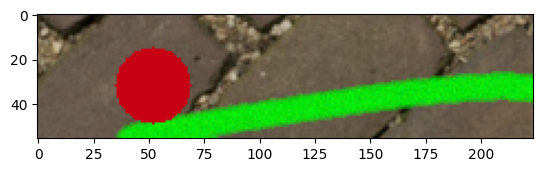

In [ ]:
imgs = load_in_memory(90,1024,1024,'ds/textures')
crop = get_random_img_crop(imgs,indexes)
alfa,img, mask= angle_to_CM_Curved(crop,get_random_coord_bezier(H,W),10,(10,230,11))
img_red, img_green = draw_semaphore(img,mask)
plt.imshow(img_red)

In [ ]:
import json
from pathlib import Path
import cv2

NORM_FACTOR = 90

LABELS = {'NO_SEM': 0,'GREEN' : 1, 'RED': 2}

def gen_ds(imgs_path = Path('ds/images'),labels_path = Path('ds/labels')):
  label_dict = dict()
  imgs_path.mkdir(parents=True, exist_ok=True)
  labels_path.mkdir(parents=True, exist_ok=True)
  i = 0
  for angle in range(-70, 71,3):
    print(f'immagini per angolo {angle-1} generate')
    for thickness in range(3,22,4):
        for offset in range(-80,81,20):
          line_color = np.random.randint(0, 256, size=3).tolist()
          sigma = np.random.rand(1) * 15 + 5
          crop = get_random_img_crop(imgs,indexes)
          img, mask = gen_image_patch_background(crop,angle,offset,line_color,thickness,sigma)
          # Salva l'immagine
          cv2.imwrite(str(imgs_path / f'img_{i}.png'), cv2.cvtColor(img,cv2.COLOR_RGB2BGR))
          img_red, img_green = draw_semaphore(img,mask) # disegniamo i semafori
          # salviamo le immagini con i semafori
          cv2.imwrite(str(imgs_path / f'img_{i+1}.png'), cv2.cvtColor(img_red,cv2.COLOR_RGB2BGR))
          cv2.imwrite(str(imgs_path / f'img_{i+2}.png'), cv2.cvtColor(img_green,cv2.COLOR_RGB2BGR))
          target_label = angle
          if offset != 0:
            target_label = angle_to_CM(H, W, angle, offset, thickness)
          label_dict[str(i)] = [target_label / NORM_FACTOR, LABELS['NO_SEM']]
          label_dict[str(i+1)] = [target_label / NORM_FACTOR, LABELS['RED']]
          label_dict[str(i+2)] = [target_label / NORM_FACTOR, LABELS['GREEN']]
          i += 3
  for j in range(8800):
    line_color = np.random.randint(0, 256, size=3).tolist()
    sigma = np.random.rand(1) * 15 + 5
    thickness = np.random.randint(3,18)
    crop = get_random_img_crop(imgs,indexes)
    alfa, img, mask = angle_to_CM_Curved(crop,get_random_coord_bezier(H,W),thickness,line_color,sigma)
    cv2.imwrite(str(imgs_path / f'img_{i}.png'), cv2.cvtColor(img,cv2.COLOR_RGB2BGR))
    label_dict[str(i)] = [alfa / NORM_FACTOR, LABELS['NO_SEM']]
    img_red, img_green = draw_semaphore(img,mask) # disegniamo i semafori
    # Salva l'immagine
    cv2.imwrite(str(imgs_path / f'img_{i+1}.png'), cv2.cvtColor(img_red,cv2.COLOR_RGB2BGR))
    cv2.imwrite(str(imgs_path / f'img_{i+2}.png'), cv2.cvtColor(img_green,cv2.COLOR_RGB2BGR))
    label_dict[str(i+1)] = [alfa / NORM_FACTOR, LABELS['RED']]
    label_dict[str(i+2)] = [alfa / NORM_FACTOR, LABELS['GREEN']]
    i += 3 # aggiorniamo di 3, abbiamo scritto 3 immagini

  with open(labels_path / 'labels.json', 'w') as f:
      json.dump(label_dict, f, indent=2)

In [ ]:
gen_ds()

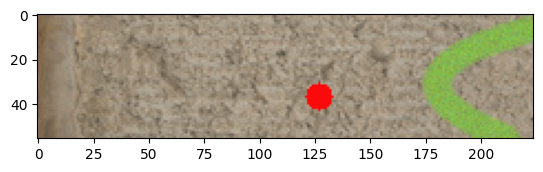

In [ ]:
sample = plt.imread('ds/images/img_12895.png')
plt.imshow(sample)

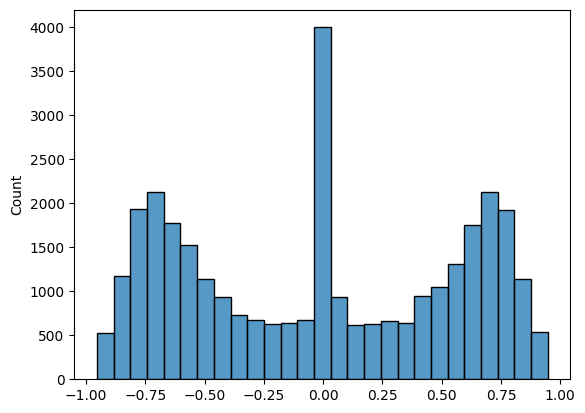

In [ ]:
import seaborn as sns

with open('ds/labels/labels.json', 'r') as f:
  labels = json.load(f)
  labels = np.array(list(labels.values()))
  angles = labels[:,0]
  sns.histplot(angles)

In [ ]:
import tensorflow as tf
from tensorflow import keras
from google.colab import drive
import matplotlib.pyplot as plt
import re
from sklearn.model_selection import train_test_split
import pandas as pd

BATCH_SZ = 64

def load_and_process_image(path, angle,sem_state):
    """ restituisce il tensore 3d (l'immagine) e la label associata al path che prende in input"""
    img_raw = tf.io.read_file(path)
    img = tf.io.decode_png(img_raw, channels=3)
    img = tf.image.resize(img, (H,W))
    # normalizzare
    img = img / 255.0
    return img, {'angle':angle,'sem_state':sem_state}

def load_ds(ds_path : Path):
    """ restituisce i dataset di training, validation e test"""
    imgs_path = ds_path / 'images'
    labels_path = ds_path / 'labels' / 'labels.json'
    with open(labels_path, 'r') as f:
      labels = json.load(f)
      labels = np.array(list(labels.values()))
      # la conversione a float32 è richiesta da tensorflow, che non accetta
      # float64 (il default di numpy)
      angles = labels[:,0].astype(np.float32)
      # sem_states sono label categoriche, quindi facciamo il cast a int
      sem_states = labels[:,1].astype(np.int32)

    regex = re.compile(r"img_(\d+)\.png")
    # imgs_path è una lista ordinata di path delle immagini.
    imgs_path = sorted(
        map(lambda x:str(x),imgs_path.glob('img_*.png')),
        key=lambda x: int(regex.search(x).group(1))
        )

    df = pd.DataFrame({'path': imgs_path,'angle':angles,'sem_state': sem_states})

    unique_angles_df = pd.DataFrame({'angle': df['angle'].unique()})
    unique_angles_df['angle_bin'] = pd.qcut(unique_angles_df['angle'], q=10, labels=False, duplicates='drop')

    df = df.merge(unique_angles_df, on='angle')

    train_angles, test_angles = train_test_split(
        unique_angles_df['angle'],
        test_size=0.2,
        stratify=unique_angles_df['angle_bin'],
        random_state=42
    )

    train_angles, val_angles = train_test_split(
        train_angles,
        test_size=0.25,
        stratify=unique_angles_df.set_index('angle').loc[train_angles]['angle_bin'],
        random_state=42
    )

    train_df = df[df['angle'].isin(train_angles)]
    val_df = df[df['angle'].isin(val_angles)]
    test_df = df[df['angle'].isin(test_angles)]

    train_ds = make_ds(train_df,is_training=True)
    val_ds = make_ds(val_df)
    test_ds = make_ds(test_df)

    return train_ds,val_ds,test_ds

def load_ds2(ds_path : Path):
  """ restituisce i dataset di training, validation e test"""
  imgs_path = ds_path / 'images'
  labels_path = ds_path / 'labels' / 'labels.json'
  with open(labels_path, 'r') as f:
    labels = json.load(f)
    labels = np.array(list(labels.values()))
    # la conversione a float32 è richiesta da tensorflow, che non accetta
    # float64 (il default di numpy)
    angles = labels[:,0].astype(np.float32)
    # sem_states sono label categoriche, quindi facciamo il cast a int
    sem_states = labels[:,1].astype(np.int32)

  regex = re.compile(r"img_(\d+)\.png")
  # imgs_path è una lista ordinata di path delle immagini.
  imgs_path = sorted(
      map(lambda x:str(x),imgs_path.glob('img_*.png')),
      key=lambda x: int(regex.search(x).group(1))
      )

  df = pd.DataFrame({'path': imgs_path,'angle':angles,'sem_state': sem_states})

  train_df, test_df = train_test_split(
      df,
      test_size=0.2,
      random_state=1
  )

  train_df, val_df = train_test_split(
      train_df,
      test_size=0.25,
      random_state=1
  )

  train_ds = make_ds(train_df,is_training=True)
  val_ds = make_ds(val_df)
  test_ds = make_ds(test_df)
  return train_ds,val_ds,test_ds

def make_ds(df,is_training = False):
  """ prende in input un df pandas e restituisce un dataset di tensorflow"""
  paths, angles, sem_states = df['path'].values, df['angle'].values, df['sem_state'].values
  ds = tf.data.Dataset.from_tensor_slices((paths,angles,sem_states))
  if is_training:
    ds = ds.shuffle(buffer_size=paths.shape[0])
  ds = ds.map(load_and_process_image, num_parallel_calls=tf.data.AUTOTUNE)
  ds = ds.batch(BATCH_SZ).prefetch(buffer_size=tf.data.AUTOTUNE)
  return ds

In [ ]:
def make_model():
  # input: abbiamo già normalizzato l'immagine nella fase di preprocessing
  inputs = keras.layers.Input(shape=(H,W,3))

  # layer convoluzionali con stride
  x = keras.layers.Conv2D(24, kernel_size=(5,5),strides=(2,2), activation='elu',padding='same')(inputs)
  x = keras.layers.Conv2D(36, kernel_size=(5,5),strides=(2,2), activation='elu',padding='same')(x)
  x = keras.layers.Conv2D(48, kernel_size=(5,5),strides=(2,2), activation='elu',padding='same')(x)
  x = keras.layers.Conv2D(64, kernel_size=(3,3), activation='elu',padding='same')(x)
  x = keras.layers.Conv2D(64, kernel_size=(3,3), activation='elu',padding='same')(x)
  # flatten
  x = keras.layers.Flatten()(x)

  #layer densi condivisi dai branch
  x = keras.layers.Dense(1000, activation='elu',kernel_initializer="he_normal")(x)
  x = keras.layers.Dropout(0.2)(x)
  x = keras.layers.Dense(100, activation='elu',kernel_initializer="he_normal")(x)
  x = keras.layers.Dropout(0.2)(x)
  x = keras.layers.Dense(50, activation='elu',kernel_initializer="he_normal")(x)

  # ogni branch ha un suo penultimo layer denso con 10 neuroni
  y_angle = keras.layers.Dense(10, activation='elu',kernel_initializer='he_normal')(x)
  y_sem_state = keras.layers.Dense(10, activation='elu',kernel_initializer='he_normal')(x)

  # ultimi layer, rispettivamente softmax per lo stato del semaforo e tanh per l'angolo
  y_angle = keras.layers.Dense(1, activation='tanh',name='angle')(y_angle)
  y_sem_state = keras.layers.Dense(3, activation='softmax',name='sem_state')(y_sem_state)

  model = keras.models.Model(inputs=inputs, outputs=[y_angle,y_sem_state])
  return model

def make_model2():
  # input: abbiamo già normalizzato l'immagine nella fase di preprocessing
  inputs = keras.layers.Input(shape=(H,W,3))

  # layer convoluzionali con stride
  x = keras.layers.Conv2D(24, kernel_size=(5,5),strides=(2,2), activation='elu',padding='same')(inputs)
  x = keras.layers.Conv2D(36, kernel_size=(5,5),strides=(2,2), activation='elu',padding='same')(x)
  x = keras.layers.Conv2D(48, kernel_size=(5,5),strides=(2,2), activation='elu',padding='same')(x)
  x = keras.layers.Conv2D(64, kernel_size=(3,3), activation='elu',padding='same')(x)
  x = keras.layers.Conv2D(64, kernel_size=(3,3), activation='elu',padding='same')(x)
  # flatten
  x = keras.layers.Flatten()(x)

  #layer densi condivisi dai branch
  x = keras.layers.Dense(1000, activation='elu',kernel_initializer="he_normal")(x)
  x = keras.layers.Dropout(0.25)(x)
  x = keras.layers.Dense(100, activation='elu',kernel_initializer="he_normal")(x)
  x = keras.layers.Dropout(0.25)(x)


  # ogni branch ha 3 layer densi [50,10,out] che non condivide con l'altro
  y_angle = keras.layers.Dense(50, activation='elu',kernel_initializer="he_normal")(x)
  y_sem_state = keras.layers.Dense(50, activation='elu',kernel_initializer="he_normal")(x)

  y_angle = keras.layers.Dense(10, activation='elu',kernel_initializer='he_normal')(y_angle)
  y_sem_state = keras.layers.Dense(10, activation='elu',kernel_initializer='he_normal')(y_sem_state)

  # ultimi layer, rispettivamente softmax per lo stato del semaforo e tanh per l'angolo
  y_angle = keras.layers.Dense(1, activation='linear',name='angle')(y_angle)
  y_sem_state = keras.layers.Dense(3, activation='softmax',name='sem_state')(y_sem_state)

  model = keras.models.Model(inputs=inputs, outputs=[y_angle,y_sem_state])
  return model

def make_model3():
  # input: abbiamo già normalizzato l'immagine nella fase di preprocessing
  inputs = keras.layers.Input(shape=(H,W,3))

  # layer convoluzionali con stride
  x = keras.layers.Conv2D(24, kernel_size=(5,5),strides=(2,2), activation='elu',padding='same')(inputs)
  x = keras.layers.Conv2D(36, kernel_size=(5,5),strides=(2,2), activation='elu',padding='same')(x)
  x = keras.layers.Conv2D(48, kernel_size=(5,5),strides=(2,2), activation='elu',padding='same')(x)
  x = keras.layers.Conv2D(64, kernel_size=(3,3), activation='elu',padding='same')(x)
  x = keras.layers.Conv2D(64, kernel_size=(3,3), activation='elu',padding='same')(x)
  # global average pooling layer invece di flatten
  x = keras.layers.GlobalAveragePooling2D()(x)

  #layer densi condivisi dai branch
  x = keras.layers.Dense(256, activation='elu',kernel_initializer="he_normal")(x)
  x = keras.layers.Dropout(0.3)(x)
  x = keras.layers.Dense(64, activation='elu',kernel_initializer="he_normal")(x)
  x = keras.layers.Dropout(0.3)(x)


  # ogni branch ha 3 layer densi [50,10,out] che non condivide con l'altro
  y_angle = keras.layers.Dense(50, activation='elu',kernel_initializer="he_normal")(x)
  y_sem_state = keras.layers.Dense(50, activation='elu',kernel_initializer="he_normal")(x)

  y_angle = keras.layers.Dense(10, activation='elu',kernel_initializer='he_normal')(y_angle)
  y_sem_state = keras.layers.Dense(10, activation='elu',kernel_initializer='he_normal')(y_sem_state)

  # ultimi layer, rispettivamente softmax per lo stato del semaforo e tanh per l'angolo
  y_angle = keras.layers.Dense(1, activation='tanh',name='angle')(y_angle)
  y_sem_state = keras.layers.Dense(3, activation='softmax',name='sem_state')(y_sem_state)

  model = keras.models.Model(inputs=inputs, outputs=[y_angle,y_sem_state])
  return model

def make_model4():
  inputs = keras.layers.Input(shape=(H,W,3))

  x = keras.layers.Conv2D(24, (5,5), strides=(2,2), activation='elu', padding='same')(inputs)
  x = keras.layers.Conv2D(36, (5,5), strides=(2,2), activation='elu', padding='same')(x)
  x = keras.layers.Conv2D(48, (5,5), strides=(2,2), activation='elu', padding='same')(x)
  x = keras.layers.Conv2D(64, (3,3), activation='elu', padding='same')(x)
  x = keras.layers.Conv2D(64, (3,3), activation='elu', padding='same')(x)

  x = keras.layers.Flatten()(x)

  x = keras.layers.Dense(256, activation='elu', kernel_initializer="he_normal")(x)
  x = keras.layers.Dropout(0.2)(x)
  x = keras.layers.Dense(64, activation='elu', kernel_initializer="he_normal")(x)
  x = keras.layers.Dropout(0.2)(x)

  y_angle = keras.layers.Dense(50, activation='elu', kernel_initializer="he_normal")(x)
  y_angle = keras.layers.Dense(10, activation='elu', kernel_initializer='he_normal')(y_angle)

  y_angle = keras.layers.Dense(1, activation='linear', name='angle')(y_angle)

  y_sem_state = keras.layers.Dense(50, activation='elu', kernel_initializer="he_normal")(x)
  y_sem_state = keras.layers.Dense(10, activation='elu', kernel_initializer='he_normal')(y_sem_state)
  y_sem_state = keras.layers.Dense(3, activation='softmax', name='sem_state')(y_sem_state)

  model = keras.models.Model(inputs=inputs, outputs=[y_angle, y_sem_state])
  return model

def make_model5():

    inputs = keras.layers.Input(shape=(H,W,3))

    # LAYER CONDIVISI
    x = keras.layers.Conv2D(24, (5,5), strides=(2,2), activation='elu', padding='same')(inputs)
    x = keras.layers.Conv2D(36, (5,5), strides=(2,2), activation='elu', padding='same')(x)
    x = keras.layers.Conv2D(48, (5,5), strides=(2,2), activation='elu', padding='same')(x)
    x = keras.layers.Conv2D(64, (3,3), activation='elu', padding='same')(x)
    x = keras.layers.Conv2D(64, (3,3), activation='elu', padding='same')(x)

    shared_features = keras.layers.Flatten()(x)

    # BRANCH 1: REGRESSIONE
    y_angle = keras.layers.Dense(256, activation='elu', kernel_initializer="he_normal")(shared_features)
    y_angle = keras.layers.Dropout(0.3)(y_angle)
    y_angle = keras.layers.Dense(128, activation='elu', kernel_initializer="he_normal")(y_angle)
    y_angle = keras.layers.Dropout(0.3)(y_angle)
    y_angle = keras.layers.Dense(64, activation='elu', kernel_initializer="he_normal")(y_angle)
    y_angle = keras.layers.Dense(1, activation='linear', name='angle')(y_angle)

    # BRANCH 2: SEMAFORO
    y_sem = keras.layers.Dense(256, activation='elu', kernel_initializer="he_normal")(shared_features)
    y_sem = keras.layers.Dropout(0.3)(y_sem)
    y_sem = keras.layers.Dense(128, activation='elu', kernel_initializer="he_normal")(y_sem)
    y_sem = keras.layers.Dropout(0.3)(y_sem)
    y_sem = keras.layers.Dense(64, activation='elu', kernel_initializer="he_normal")(y_sem)
    y_sem = keras.layers.Dense(3, activation='softmax', name='sem_state')(y_sem)

    model = keras.models.Model(inputs=inputs, outputs=[y_angle, y_sem])
    return model

def make_model6():
    inputs = keras.layers.Input(shape=(H,W,3))

    # LAYER CONDIVISI
    x = keras.layers.Conv2D(24, (5,5), strides=(2,2), activation='elu', padding='same')(inputs)
    x = keras.layers.Conv2D(36, (5,5), strides=(2,2), activation='elu', padding='same')(x)
    x = keras.layers.Conv2D(48, (5,5), strides=(2,2), activation='elu', padding='same')(x)
    x = keras.layers.Conv2D(64, (3,3), activation='elu', padding='same')(x)
    x = keras.layers.Conv2D(64, (3,3), activation='elu', padding='same')(x)

    shared_features = keras.layers.GlobalAveragePooling2D()(x)

    # BRANCH 1: REGRESSIONE
    y_angle = keras.layers.Dense(128, activation='elu', kernel_initializer="he_normal")(shared_features)
    y_angle = keras.layers.Dropout(0.3)(y_angle)
    y_angle = keras.layers.Dense(64, activation='elu', kernel_initializer="he_normal")(y_angle)
    y_angle = keras.layers.Dense(1, activation='linear', name='angle')(y_angle)

    # BRANCH 2: SEMAFORO
    y_sem = keras.layers.Dense(128, activation='elu', kernel_initializer="he_normal")(shared_features)
    y_sem = keras.layers.Dropout(0.3)(y_sem)
    y_sem = keras.layers.Dense(64, activation='elu', kernel_initializer="he_normal")(y_sem)
    y_sem = keras.layers.Dense(3, activation='softmax', name='sem_state')(y_sem)

    model = keras.models.Model(inputs=inputs, outputs=[y_angle, y_sem])
    return model

initial_learning_rate = 1e-3

lr_scheduler = keras.callbacks.ReduceLROnPlateau(
    monitor='val_angle_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

optimizer = keras.optimizers.Adam(learning_rate=initial_learning_rate)

In [ ]:
model = make_model6()
model.compile(
    optimizer=optimizer,
    loss={
        "angle": "huber",
        "sem_state": "sparse_categorical_crossentropy",
    },
    loss_weights={
    "angle": 0.6,
    "sem_state": 0.4,
    },
    metrics={
        "angle": "mae",
        "sem_state": "sparse_categorical_accuracy",
    },
)

In [ ]:
train,val,test = load_ds2(Path("ds"))

In [ ]:
history = model.fit(
    train,
    epochs = 70,
    validation_data = val,
    # dobbiamo monitorare la angle_loss, l'accuracy per i semafori è già alta dalla prime epoche
    callbacks=[keras.callbacks.EarlyStopping(patience=10,restore_best_weights=True,monitor='val_angle_loss',mode='min'),
               lr_scheduler]
    )

Epoch 1/70
307/307 ━━━━━━━━━━━━━━━━━━━━ 28s 60ms/step - angle_loss: 0.1697 - angle_mae: 0.5056 - loss: 0.5390 - sem_state_loss: 1.0931 - sem_state_sparse_categorical_accuracy: 0.3863 - val_angle_loss: 0.1628 - val_angle_mae: 0.4973 - val_loss: 0.5306 - val_sem_state_loss: 1.0827 - val_sem_state_sparse_categorical_accuracy: 0.4173 - learning_rate: 0.0010
Epoch 2/70
307/307 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - angle_loss: 0.1626 - angle_mae: 0.4967 - loss: 0.5215 - sem_state_loss: 1.0597 - sem_state_sparse_categorical_accuracy: 0.4182 - val_angle_loss: 0.1616 - val_angle_mae: 0.4942 - val_loss: 0.3903 - val_sem_state_loss: 0.7331 - val_sem_state_sparse_categorical_accuracy: 0.6047 - learning_rate: 0.0010
Epoch 3/70
307/307 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - angle_loss: 0.1693 - angle_mae: 0.5048 - loss: 0.3774 - sem_state_loss: 0.6896 - sem_state_sparse_categorical_accuracy: 0.6453 - val_angle_loss: 0.1621 - val_angle_mae: 0.4931 - val_loss: 0.2675 - val_sem_state_loss: 0.4256 - val_se

In [ ]:
model.evaluate(test)

103/103 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - angle_loss: 0.0076 - angle_mae: 0.0633 - loss: 0.0433 - sem_state_loss: 0.0968 - sem_state_sparse_categorical_accuracy: 0.9904


[0.036220718175172806,
 0.007685068063437939,
 0.07846178859472275,
 0.06383514404296875,
 0.9912964105606079]

In [ ]:
import pandas as pd
from pandas import DataFrame

df = DataFrame(history.history)
df.columns

Index(['angle_loss', 'angle_mae', 'loss', 'sem_state_loss',
       'sem_state_sparse_categorical_accuracy', 'val_angle_loss',
       'val_angle_mae', 'val_loss', 'val_sem_state_loss',
       'val_sem_state_sparse_categorical_accuracy', 'learning_rate'],
      dtype='object')

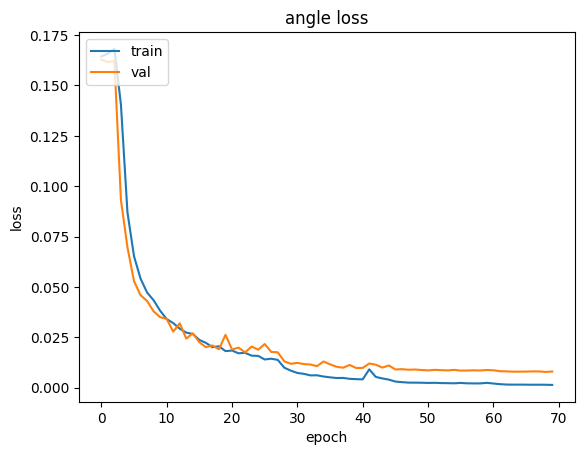

In [ ]:
plt.plot(df['angle_loss'])
plt.plot(df['val_angle_loss'])
plt.title('angle loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')

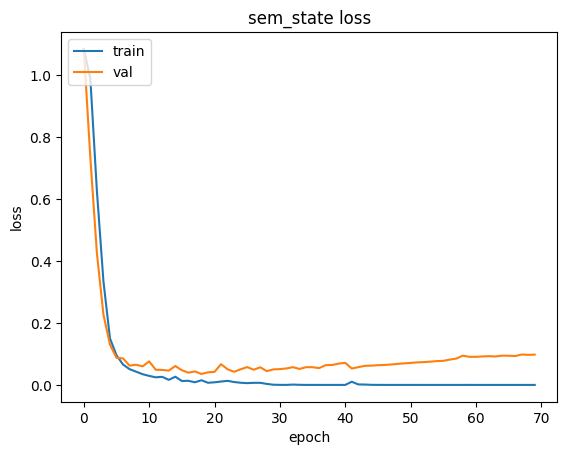

In [ ]:
plt.plot(df['sem_state_loss'])
plt.plot(df['val_sem_state_loss'])
plt.title('sem_state loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')

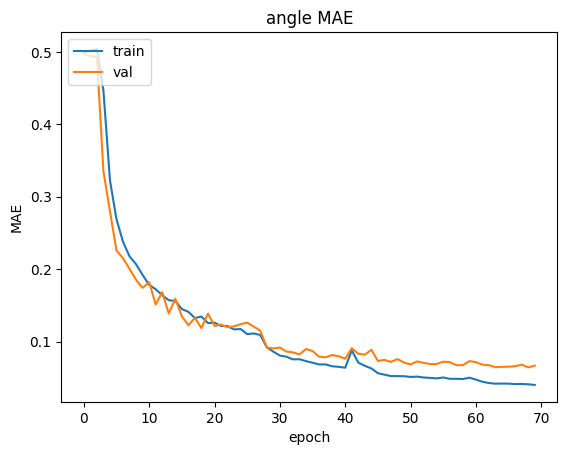

In [ ]:
plt.plot(df['angle_mae'])
plt.plot(df['val_angle_mae'])
plt.title('angle MAE')
plt.ylabel('MAE')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')

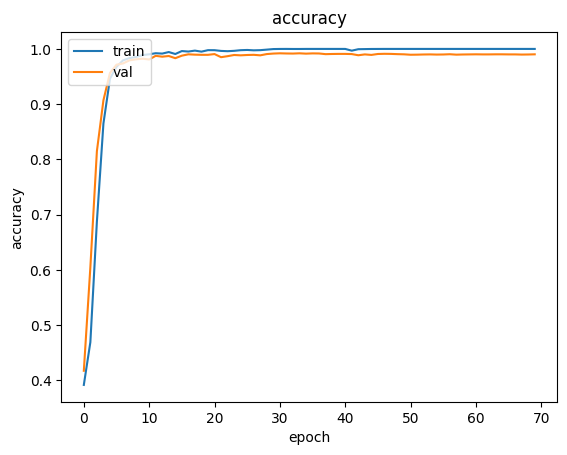

In [ ]:
plt.plot(df['sem_state_sparse_categorical_accuracy'])
plt.plot(df['val_sem_state_sparse_categorical_accuracy'])
plt.title('accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')

In [ ]:
def preprocess_for_model(img):
  """abbiamo bisogno di questa funzione perchè opencv restituisce dei tensori
    BGR, di tipo uint8. Il modello prende in input delle immagini RGB di tipo
    float32"""
  img_rgb = img #cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
  img_resized = img #cv2.resize(img_rgb, (H,W))
  img_normalized = img_resized.astype(np.float32) / 255.0
  # dobbiamo aggiungere una dimensione (quella di batch) al tensore 3d
  img_batch = np.expand_dims(img_normalized, axis=0)
  return img_batch

In [ ]:
angle_preds,sem_preds = model.predict(test)
preds = np.array(angle_preds)
y_true = np.concatenate([x[1]['angle'] for x in test], axis=0)
res = y_true - preds.flatten()

103/103 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step


In [ ]:
df = pd.DataFrame({
    'y_true': y_true * 90,
    'abs_error': np.abs(y_true - preds.flatten()) * 90
})

/tmp/ipykernel_393/3690958018.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_analysis = df.groupby('y_bins')['abs_error'].mean().reset_index()


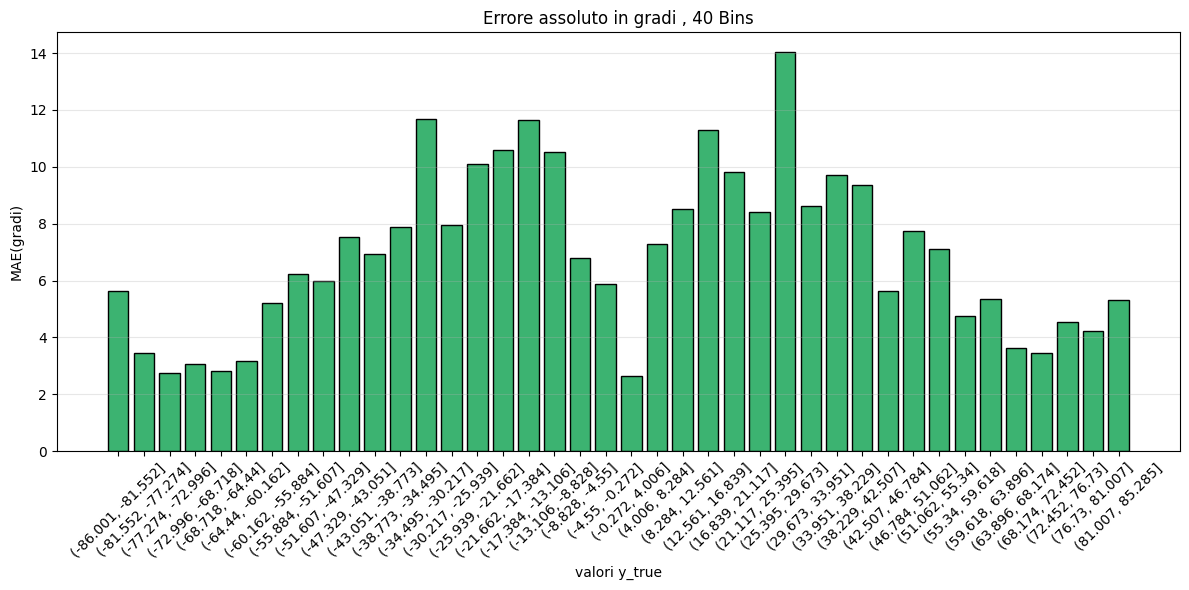

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Define the number of bins you want (e.g., 10 or 20)
n_bins = 40

# 2. Use pd.cut to create ranges
df['y_bins'] = pd.cut(df['y_true'], bins=n_bins)

# 3. Calculate Mean Absolute Error for each bin
bin_analysis = df.groupby('y_bins')['abs_error'].mean().reset_index()

# 4. Plot
plt.figure(figsize=(12, 6))
# Convert bin intervals to strings for the x-axis labels
plt.bar(bin_analysis['y_bins'].astype(str), bin_analysis['abs_error'],
        color='mediumseagreen', edgecolor='black')

plt.xticks(rotation=45)
plt.xlabel('valori y_true')
plt.ylabel('MAE(gradi)')
plt.title(f'Errore assoluto in gradi , 40 Bins')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

keras.models.save_model(model,filepath='/content/drive/MyDrive/Tesi/models/model_nvidia_13/model.keras')

Mounted at /content/drive


In [ ]:
with open('/content/drive/MyDrive/Tesi/models/model_nvidia_13/history.json','w') as f:
  json.dump(history.history,f,indent=2)

In [ ]:
!ls ds/images | grep ".png" | wc -l

32745


In [ ]:
import shutil

samples = np.random.randint(0,32745,5).tolist()
for j in samples:
  shutil.copy(f'/content/ds/images/img_{j}.png',f'/content/drive/MyDrive/Tesi/models/model_nvidia_13')

In [ ]:
with open('ds/labels/labels.json') as f:
  labels = json.load(f)
  labels = np.array(list(labels.values()))
  angles = labels[:,0].astype(np.float32)

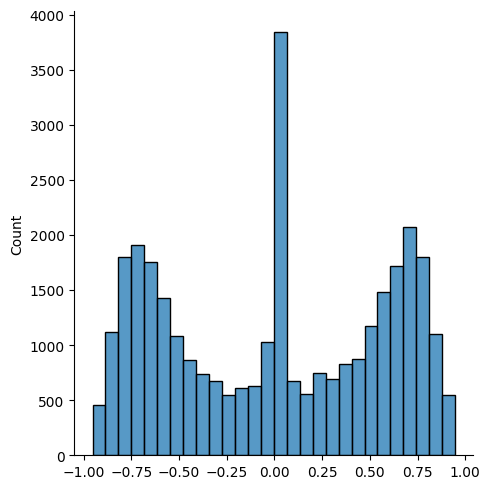

In [ ]:
import seaborn as sns
sns.displot(angles).savefig('angle_distribution.png')

In [ ]:
shutil.copy('angle_distribution.png',f'/content/drive/MyDrive/Tesi/models/model_nvidia_13')

'/content/drive/MyDrive/Tesi/models/model_nvidia_12/angle_distribution.png'